In [1]:
import sys

sys.path.insert(1, '../')
from Functions import *
import MetricMapping

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
datadir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Data/IntermediateFiles/'
figdir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Figures/'

In [3]:
# Access the mappings:
type_mapping = MetricMapping.type_mapping
name_mapping = MetricMapping.name_mapping

In [4]:
resolutions = ['raw', 'dblnorm']

### Get the data

In [5]:
just_5m = pd.read_csv(datadir+"/Just5m.csv")

In [6]:
# for res in resolutions:

#     del transformed_minmax_scaled[f'min_intensity{res}']
#     del transformed_minmax_scaled[f'frac_q1_wi{res}'] 
#     del transformed_minmax_scaled[f'frac_q2_wi{res}']  
#     del transformed_minmax_scaled[f'frac_q3_wi{res}']  
#     del transformed_minmax_scaled[f'frac_q4_wi{res}']  
#     del transformed_minmax_scaled[f'duration{res}']  
    
# column_names = transformed_minmax_scaled.columns.str.replace('_log', '')
# column_names = column_names.str.replace('_yj', '')
# transformed_minmax_scaled.columns = column_names

### Get a list of metrics

In [7]:
metrics = list(name_mapping.keys())
categorical_metrics = ['3rd_ARR',  '3rd_rcg',  '3rd_w_peak', '4th_w_peak', '5th_w_peak', 'third_ppr', '3rd_w_most', 
                       '4th_w_most', '5th_w_most']
continuous_metrics = [metric for metric in list(type_mapping.keys()) if metric not in categorical_metrics]

# categorical_metrics = categorical_metrics = [col + '_raw' for col in categorical_metrics]
# continuous_metrics = continuous_metrics = [col + '_raw' for col in continuous_metrics]

### Calculate statistics on the data

In [8]:
summary_df = compute_metric_sensitivity_bynormalisation(df=just_5m,
    continuous_metrics=continuous_metrics,
    categorical_metrics=categorical_metrics,
    resolutions =['dblnorm'])
summary_df["type2"] = summary_df["metric"].map(type_mapping)

dblnorm
missing column I30_raw or I30_dblnorm
missing column norm_time_std_raw or norm_time_std_dblnorm


In [9]:
# items = ['frac_q1_wi', 'frac_q2_wi', 'frac_q3_wi', 'frac_q4_wi', 'I30', 'centre_gravity_interpolated'] 
# ordered_types = list(type_mapping.keys())
# ordered_types.remove("lorenz_asymmetry")
# ordered_types = [i for i in ordered_types if i not in items]
# summary_df = summary_df.set_index('metric').loc[ordered_types].reset_index()

### Get versions of the data split by metric type`

In [10]:
df_continuous = summary_df[summary_df["type"] != "categorical"]
# df_continuous = df_continuous[df_continuous['metric'] != 'mean_intensity'].copy()
unique_metrics_continuous = df_continuous['metric'].unique().tolist()

df_categorical = summary_df[summary_df["type"] == "categorical"]
unique_metrics_categorical = df_categorical['metric'].unique().tolist()

In [11]:
def plot_histograms(ax, transformed_minmax_scaled, metric, metric_type_df, log_scale_metrics, type_color_map, resolutions):
    label_resolutions = ['5 minute', "10 minute", "30 minute", "60 minute"]
    
    for num, res in enumerate(resolutions):
        col_name = f"{metric}_{res}"
        this_type = metric_type_df[metric_type_df['metric'] == metric]['type2'].iloc[0]
        color_map = type_color_map[this_type]
        if col_name in transformed_minmax_scaled.columns:
            values = transformed_minmax_scaled[col_name].dropna()

            # Check if column is effectively constant
            if values.std() < 1e-10:
                ax.axvline(x=values.mean(), color=color_map[resolutions.index(res)],
                           linewidth=4, label=label_resolutions[num])
#                 ax.text(0.5, 0.5,
#                         f'Constant = {values.mean():.3f}\n(meaningless for \n double normalised events)',
#                         transform=ax.transAxes,
#                         ha='center', va='center',
#                         fontsize=11, color='black',
#                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                continue

            # Use log bins for specified metrics
            if metric in log_scale_metrics:
                values = values[values > 0]
                if len(values) > 0:
                    bins = 50
                    ax.set_xscale("log")
                    ax.xaxis.set_major_formatter(FuncFormatter(smart_log_tick_format))
                else:
                    continue
            else:
                bins = 20

            sns.histplot(
                values,
                bins=bins,
                kde=False,
                ax=ax,
                color=color_map[resolutions.index(res)],
                label=label_resolutions[num],
                element='step',
                stat='density',
                fill=True,
                alpha=0.8)

    title = name_mapping[metric]
    ax.set_title(title, fontsize=27, fontstyle="italic")
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=15)
    ax.grid(True)

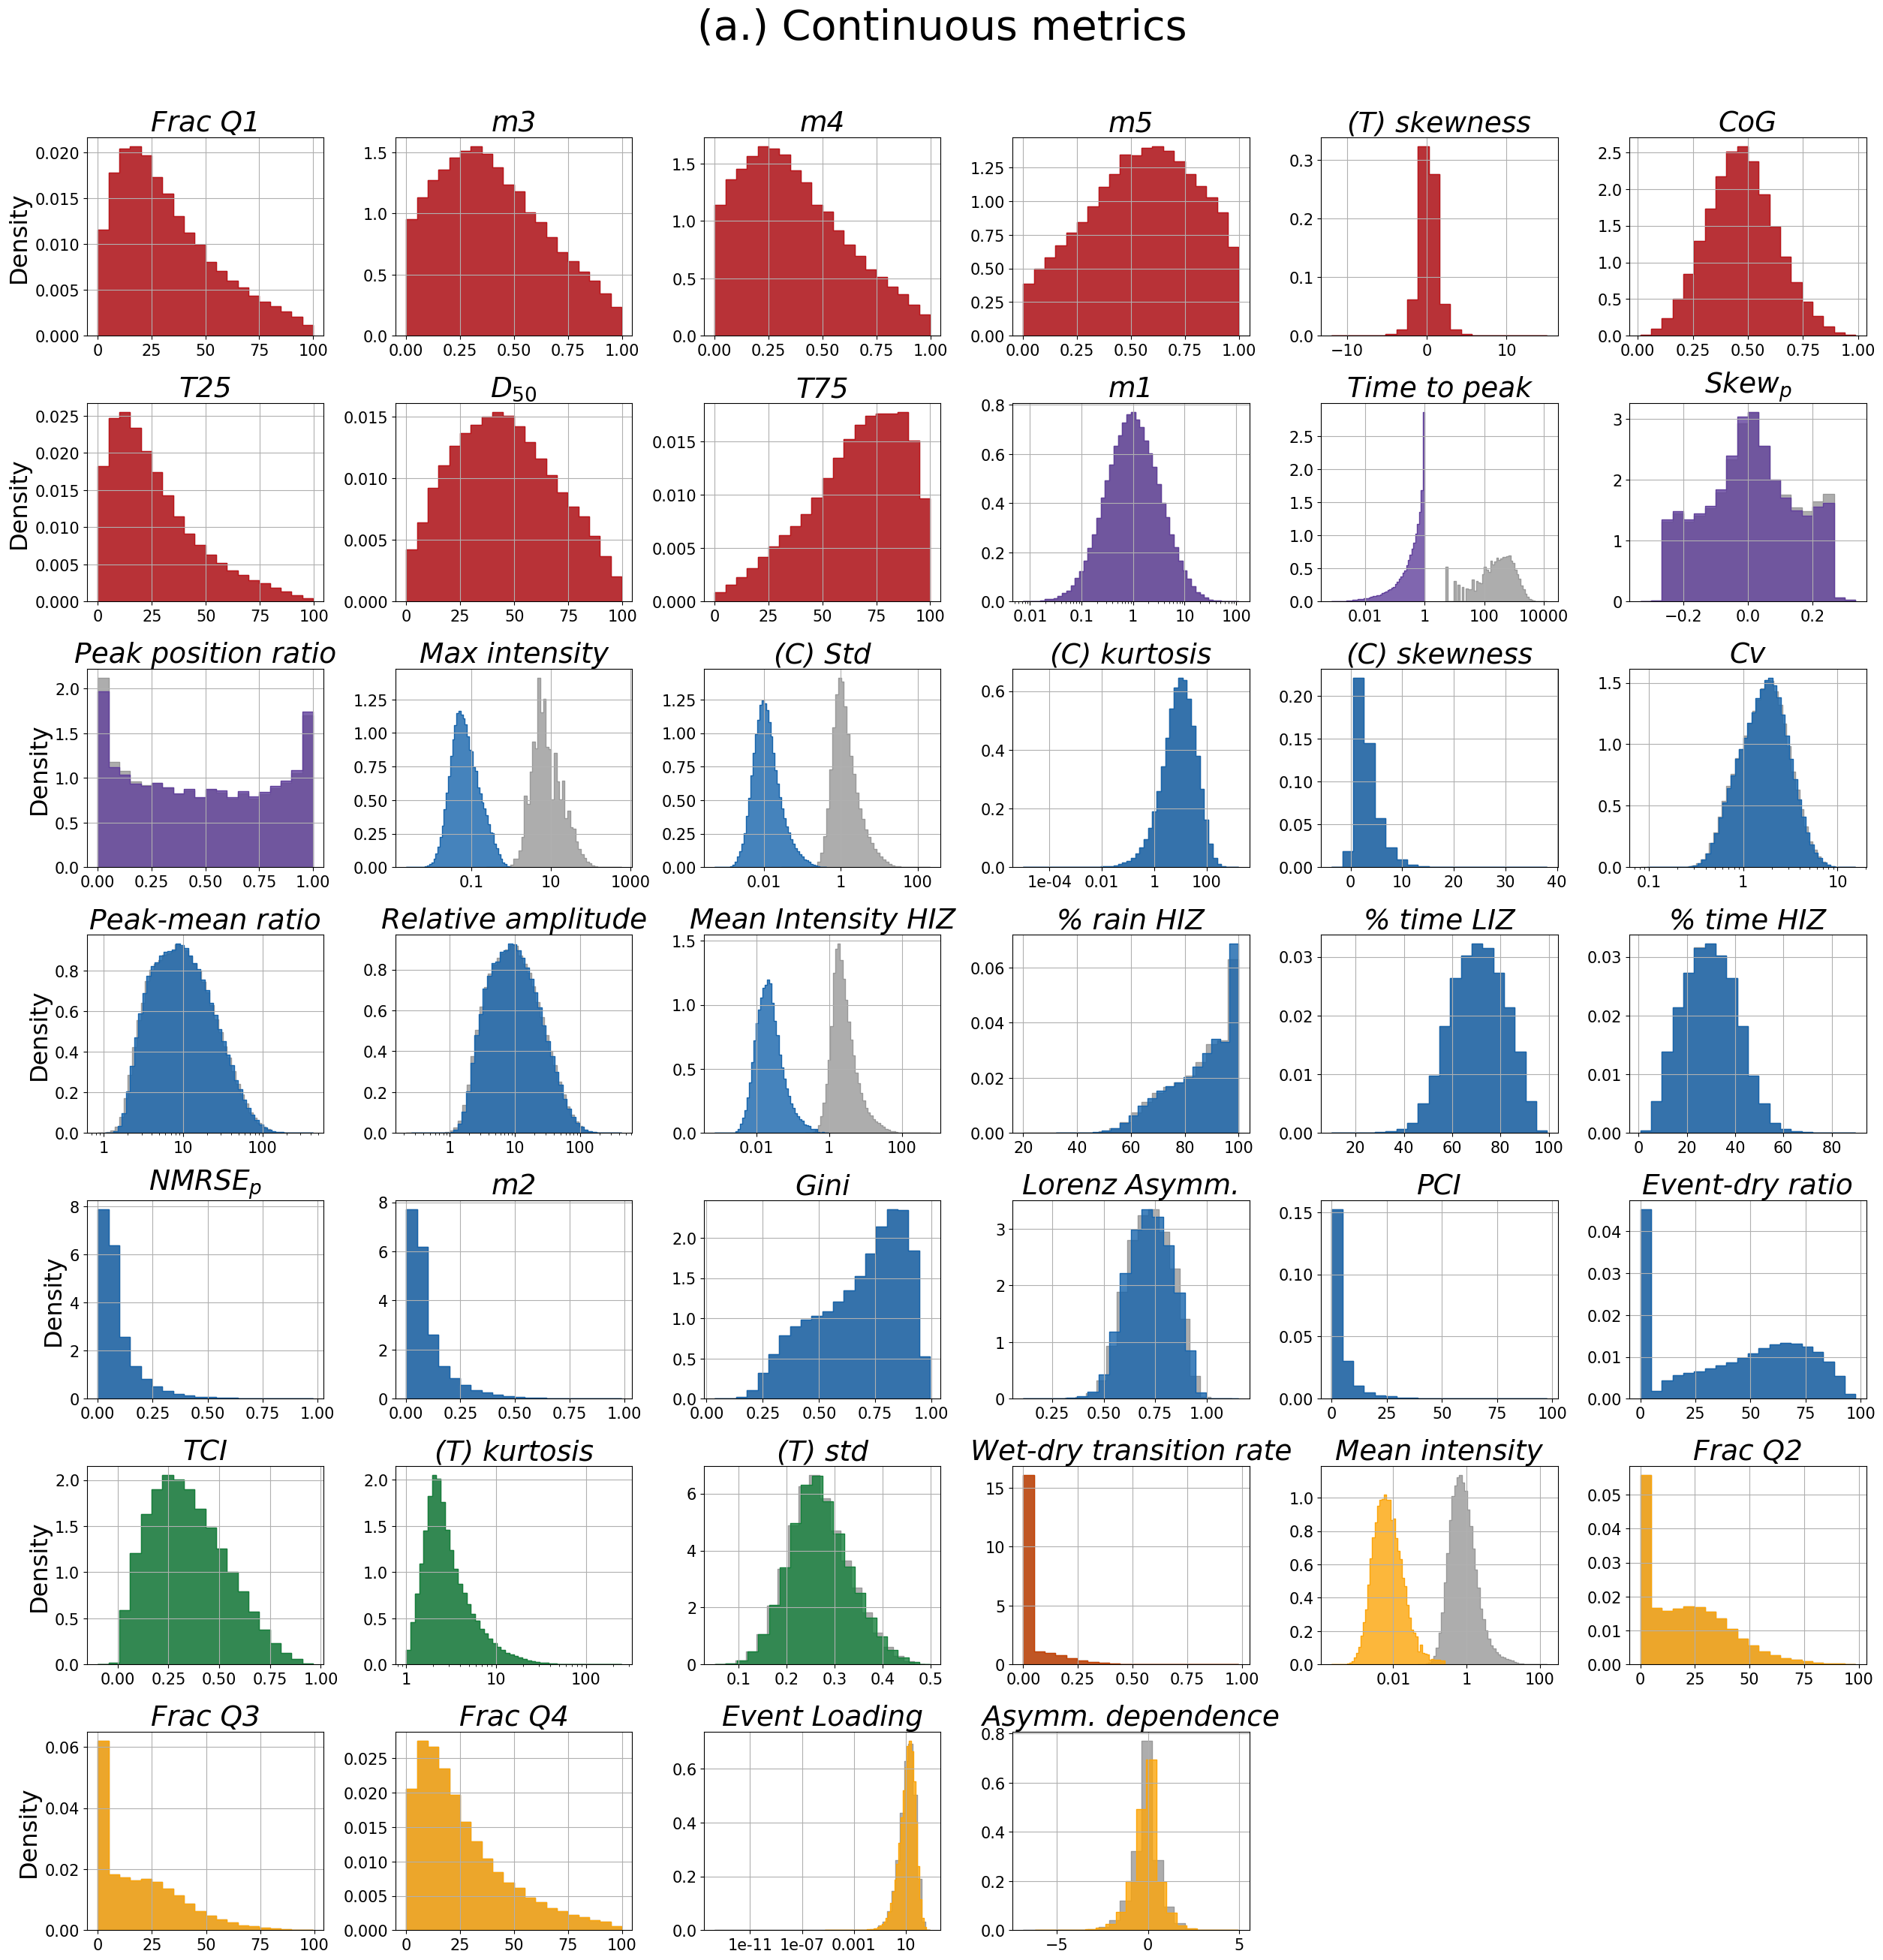

In [12]:
log_scale_metrics = [
    'mean_intensity', 'time_to_peak', 'std', 'Mean Intensity HIZ', 'm1', 'm1_wi', 'cv',
    'time_kurtosis', 'max_intensity', 'kurtosis', 'relative_amp',
    'peak_mean_ratio', 'Event Loading', 'min_intensity', 'time_std']

n_cols = 6
n_rows = -(-len(unique_metrics_continuous) // n_cols)

fig, axs = plt.subplots(ncols=n_cols,nrows=n_rows,figsize=(4.2 * n_cols, 3.8 * n_rows),sharex=False,sharey=False)

axs = axs.flatten()

# plot metrics
for i, metric in enumerate(unique_metrics_continuous):
    ax = axs[i]

    metric_data = df_continuous[df_continuous["metric"] == metric]

    plot_histograms(ax,just_5m,metric, metric_data, log_scale_metrics,type_color_map_3, resolutions)

#     if metric == 'mean_intensity':
#         ax.axvline(x=0.1, color=type_color_map_3['Magnitude concentration'][1], linewidth=2)

# remove y labels except first column
for i, ax in enumerate(axs):
    if i % n_cols == 0:
        ax.set_ylabel("Density", fontsize=23)
    else:
        ax.set_ylabel("")

# turn off unused axes
for ax in axs[len(unique_metrics_continuous):]:
    ax.axis("off")

# --- Adjust top margin for suptitle ---
fig.subplots_adjust(top=0.92)  # leave space for suptitle

fig.suptitle("(a.) Continuous metrics", fontsize=40)
plt.tight_layout(rect=[0,0,1,0.96])
# --- save with tight bbox to avoid cutting content ---
plt.show()
fig.savefig(figdir + "CompareNormalisation/histogram_continuous_metrics_dblnorm.png",dpi=300,  facecolor="white",bbox_inches='tight')

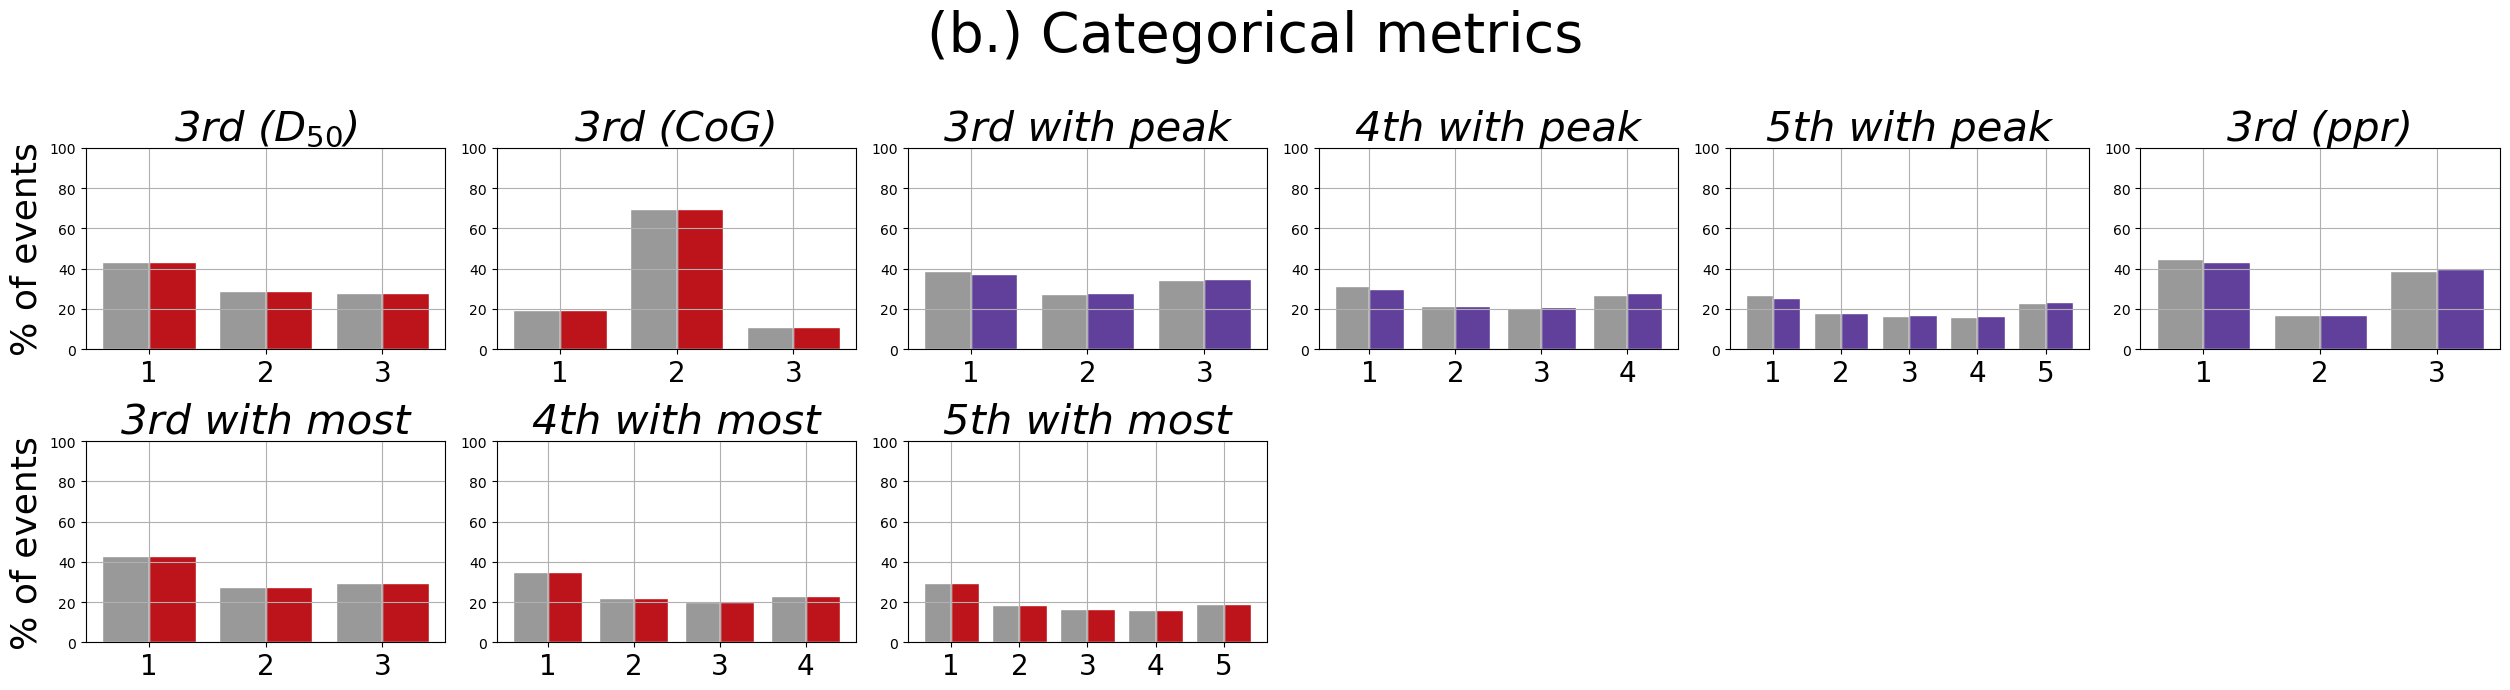

In [13]:
n_cols = 6
n_rows = -(-len(unique_metrics_categorical) // n_cols)

fig, axs = plt.subplots( ncols=n_cols, nrows=n_rows,figsize=(4.2 * n_cols, 3.5 * n_rows),sharex=False,sharey=False)

axs = axs.flatten()

for i, metric in enumerate(unique_metrics_categorical):

    metric_data = df_categorical[df_categorical["metric"] == metric]

    plot_grouped_categorical(axs[i], metric, metric_data,  just_5m, type_color_map_3,resolutions)

# turn off unused axes
for ax in axs[len(unique_metrics_categorical):]:
    ax.axis('off')

for i, ax in enumerate(axs):
    if i % n_cols == 0:
        ax.set_ylabel('% of events', fontsize=26)
    else:
        ax.set_ylabel('')

fig.suptitle("(b.) Categorical metrics", fontsize=40)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

fig.savefig(figdir+"CompareNormalisation/histogram_categorical_metrics_dblnorm.png", dpi=300, facecolor='white')

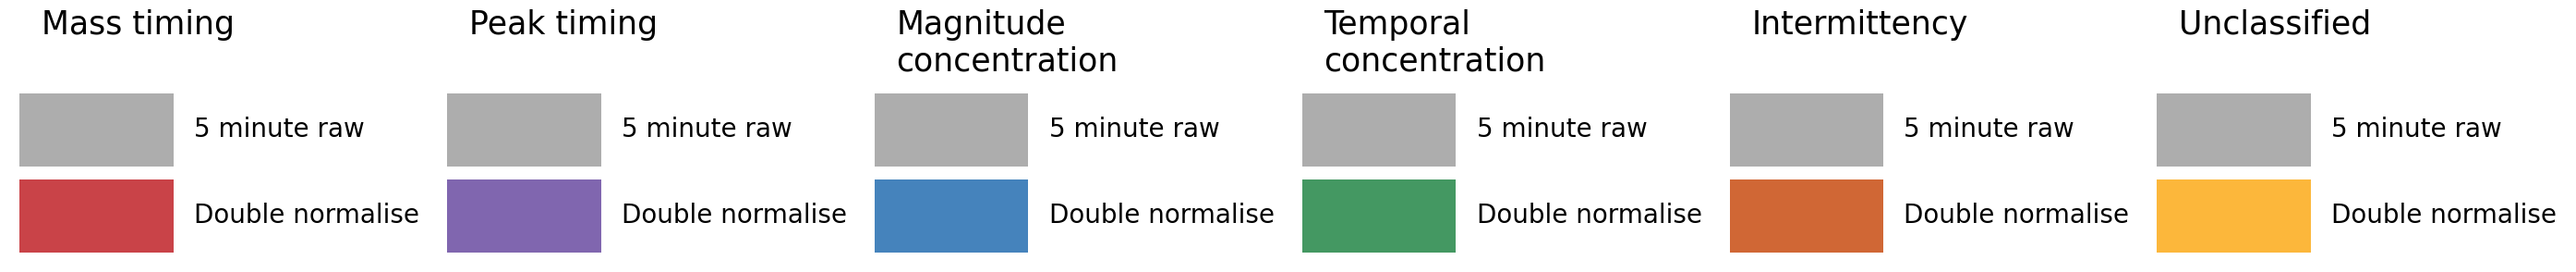

In [14]:
legend_types = list(type_color_map_3.keys())
labels = ['5 minute raw', 'Double normalise']

fig_leg, axs_leg = plt.subplots(ncols=len(legend_types),figsize=(5 * len(legend_types), 2))

if len(legend_types) == 1:
    axs_leg = [axs_leg]

for ax, metric_type in zip(axs_leg, legend_types):

    ax.axis("off")

    colors = type_color_map_3[metric_type]

    patches = [Patch(facecolor=colors[j], label=labels[j], alpha=0.8)
        for j in range(len(resolutions))]
    
    # Handle long titles
    title = metric_type.replace(" ", "\n", 1) if len(metric_type) > 20 else metric_type
    if "\n" not in title:
        title = title + "\n "  # blank second line for spacing

    # Legend without title
    ax.legend(handles=patches, title='',loc="center",frameon=False, fontsize=20, handlelength=6, handleheight=4)

    # Add text above the color boxes
    ax.text(0, 1.2, title, fontsize=25, ha='left', va='bottom', transform=ax.transAxes)

# --- manually adjust top margin so text is not cut off ---
fig_leg.subplots_adjust(top=0.85, left=0.05, right=0.95)  # adjust top, left, right margins
plt.show()
fig_leg.savefig(figdir+"CompareNormalisation/histogram_legend.png", dpi=300, facecolor='white', bbox_inches='tight')

In [15]:
from PIL import Image
import glob

# Collect images
files = sorted(glob.glob(figdir+"CompareNormalisation/histogram_continuous_metrics_dblnorm.png")) + \
        sorted(glob.glob(figdir+"CompareNormalisation/histogram_categorical_metrics_dblnorm.png")) + \
        sorted(glob.glob(figdir+"CompareNormalisation/histogram_legend.png"))

if not files:
    raise ValueError("No images found – check path or extension")

# Open all images
imgs = [Image.open(f).convert("RGB") for f in files]

# Resize to same width if needed
width = max(img.width for img in imgs)
resized = [img if img.width == width else img.resize((width, int(img.height * width / img.width)))
           for img in imgs]

# Add extra spacing after the 2nd image
spacing_after_second = 180  # pixels

# Compute total height
total_height = sum(img.height for img in resized) + spacing_after_second+ spacing_after_second

# Create canvas
canvas = Image.new("RGB", (width, total_height), (255, 255, 255))

# Paste images with spacing
y = 0
for i, img in enumerate(resized):
    canvas.paste(img, (0, y))
    y += img.height
    # add spacing after 2nd image
    if i == 0:
        y += 0
    elif i ==1:
        y += spacing_after_second

canvas.save(figdir+"CompareNormalisation/histogram_combined_dblnorm.png", dpi=(300, 300))